## Семинар 5: "Улучшение сходимости нейросетей"

ФИО: Козлов Сергей Александрович

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
%matplotlib inline

## Описание задания:
Вам необходимо реализовать оставшиеся методы из лекции и сравнить их на примере из семинара.

## Задание разделено на следующие части:
1. Реализация Xavier **(1 балл)**

2.1 Реализация DropConnect **(1 балл)**

2.2 Сравнение обучения при использовании Dropout и DropConnect **(1 балл)**

3.1 Реализация LayerNorm **(2 балл)**

## Срок выполнения задания:
Софт дедлайн - 8 октября 23:59  
Хард дедлайн - 15 октября 23:59


### Часть 1: Инициализация весов

Будем использовать MNIST для обучения:

In [3]:
# Dataloader
to_numpy = lambda x: x.numpy()
transform = transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                    ])
train_dataset = MNIST('.', train=True, download=True, transform=transform)
test_dataset = MNIST('.', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:09<00:00, 1.09MB/s]


Extracting .\MNIST\raw\train-images-idx3-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 307kB/s]


Extracting .\MNIST\raw\train-labels-idx1-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 931kB/s] 


Extracting .\MNIST\raw\t10k-images-idx3-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.76MB/s]

Extracting .\MNIST\raw\t10k-labels-idx1-ubyte.gz to .\MNIST\raw



In [4]:
images_train, labels_train = next(iter(train_loader))

In [5]:
## Usage example:
for X, y in train_loader:
    X = X.view(X.size(0), -1)
    X = X.numpy() ### Converts torch.Tensor to numpy array
    y = y.numpy()
    break

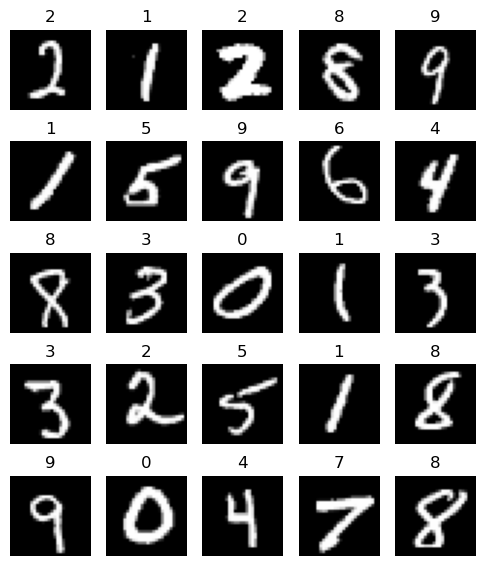

In [6]:
plt.figure(figsize=(6, 7))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.title(y[i])
    plt.axis('off')
plt.show()

In [12]:
def init_layer(layer, mean=0, std=1):
    # Тут надо быть аккуратным — можно случайно создать копию и менять значения у копии
    weight = layer.state_dict()['weight']
    bias = layer.state_dict()['bias']
    bias.zero_()
    weight.normal_(mean=0, std=std)

def forward_hook(self, input_, output):
    std = input_[0].std().item()
    print('forward', std)

def backward_hook(self, grad_input, grad_output):
    std = grad_input[0].std().item()
    print('backward', std)

На вход передаем изображение 28x28, на выходе -- вероятности 10 классов.

In [13]:
layer_1 = nn.Linear(28*28, 500)
layer_2 = nn.Linear(500, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_layer(layer_1)
init_layer(layer_2)

Соберем все вместе, используя ReLU в качестве функции активации:

In [14]:
network = nn.Sequential(
    layer_1,
    nn.ReLU(),
    layer_2
)

In [15]:
n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 1.0040135383605957
forward 16.32948112487793
backward 0.03333333507180214
backward 0.19115866720676422


#### 1.1 Реализуйте инициализацию Xavier. Сравните ее с He, которая была реализована на семинаре, сделайте выводы. Учтите, что для Xavier необходимо использовать функцию активации nn.Tanh(). **(1 балл)**

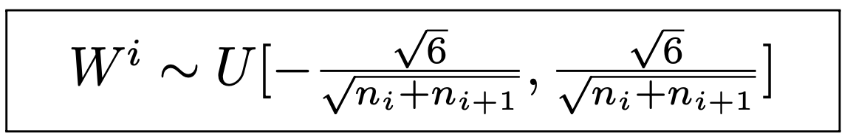

In [22]:
def init_xavier(layer):
    weight = layer.state_dict()['weight']
    bias = layer.state_dict()['bias']
    bias.zero_()
    nout, nin = layer.state_dict()['weight'].shape
    lower = - torch.sqrt(torch.tensor(6)) / (torch.sqrt(torch.tensor(nin + nout)))
    upper = torch.sqrt(torch.tensor(6)) / (torch.sqrt(torch.tensor(nin + nout)))
    weight.uniform_(lower, upper)

In [23]:
layer_1 = nn.Linear(28*28, 500)
layer_2 = nn.Linear(500, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_xavier(layer_1)
init_xavier(layer_2)

network = nn.Sequential(
    layer_1,
    nn.Tanh(),
    layer_2
)

In [25]:
n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 1.0040135383605957
forward 0.660893440246582
backward 0.03333333507180214
backward 0.012647281400859356


Если сравнивать с инициализацей He:
- std при forward почти такие же
- std градиентов во время backward отличаются, причём в инициализации He, градиенты меньше друг от друга отличаются

## Часть 2: DropConnect

#### 2.1 Реализуйте DropConnect по следующему шаблону: **(1 балл)**

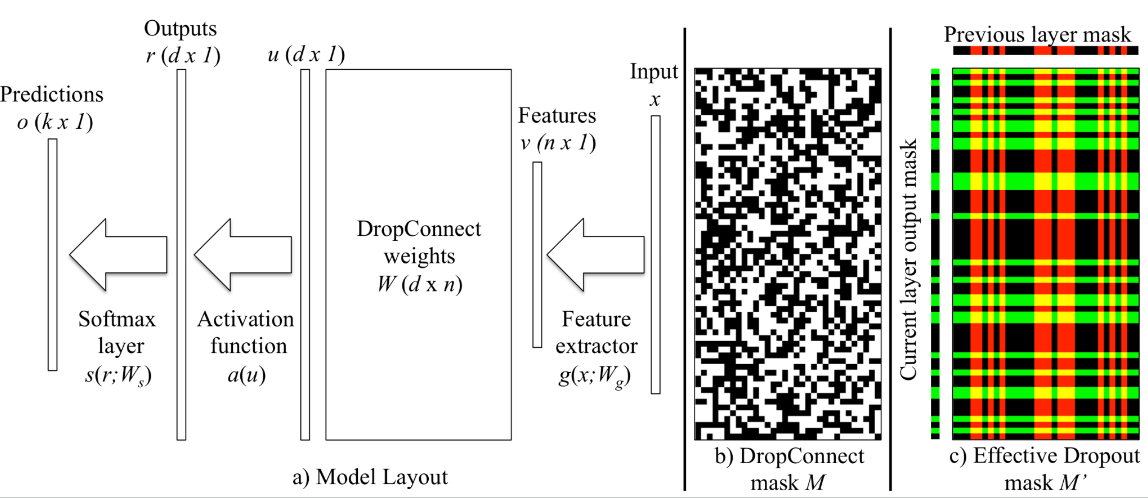

In [76]:
# полезная функция: .bernoulli_(p)
# не забывайте делать requires_grad=False у маски
# помните, что в вычислениях должны участвовать Variable, а не тензоры

class DropConnect(nn.Module):
    def __init__(self, input_dim, output_dim, p=0.5):
        super(DropConnect, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.p = p

    def forward(self, x):
        if self.training:
            mask = torch.bernoulli(torch.ones_like(self.linear.weight) * (1 - self.p))
        else:
            mask = torch.ones_like(self.linear.weight)

        mask = mask.data
        output = F.linear(x, self.linear.weight * mask, self.linear.bias)
        return output

Основа для сети, которую будем обучать:

In [77]:
class TestNetwork(nn.Module):
    def __init__(self, final_part):
        super().__init__()

        channels = 1

        self.conv_layers = nn.Sequential(
            nn.Conv2d(channels, 2, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(2, 4, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
        )

        #input_size = 7 * 7 * 4 = 196
        self.flatten = nn.Flatten()

        self.final_part = final_part

        self.log_softmax = nn.LogSoftmax(1)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.final_part(x)
        return self.log_softmax(x)

Добавим несколько слоев в конец сети:

In [89]:
layers = [
    DropConnect(196, 128),
    nn.ReLU(),
    DropConnect(128, 128),
    nn.ReLU(),
    DropConnect(128, 10)
]

In [90]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

Обучим получившуюся сеть:

In [ ]:
for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses)))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.304548
Train Epoch: 0 [12800/60000 (21%)]	Loss: 1.579086
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.905343
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.754986
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.826600
Test Epoch: 0	Loss: 2.008983
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.831701
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.548284
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.585318
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.565262
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.456801
Test Epoch: 1	Loss: 1.331415
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.515995
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.434681
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.339649
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.607439
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.388009
Test Epoch: 2	Loss: 1.158251
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.403379
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.475115
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.271976
Train Epoch: 3 [38400/60000 (64%)


#### 2.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Dropout между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и DropConnect вместо всех линейных слоев


In [92]:
class Dropout(nn.Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()
        self.p = p

    def forward(self, x):
        mask = torch.empty(x.shape).uniform_(0, 1).type(torch.FloatTensor)
        if self.training:
            mask = torch.where(mask > self.p, 1, 0)
        else:
            mask = torch.where(mask > self.p, 1, 1 - self.p)

        return x * mask

layers = [
    nn.Linear(196, 128),
    Dropout(),
    nn.ReLU(),
    nn.Linear(128, 128),
    Dropout(),
    nn.ReLU(),
    nn.Linear(128, 10)
]

network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses_dropout = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses_dropout.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses_dropout)))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.294839
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.981328
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.564988
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.464129
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.284855
Test Epoch: 0	Loss: 0.291389
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.369291
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.291382
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.260873
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.214693
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.272544
Test Epoch: 1	Loss: 0.184196
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.210746
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.192776
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.250938
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.201728
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.103554
Test Epoch: 2	Loss: 0.163497
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.188332
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.161222
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.339846
Train Epoch: 3 [38400/60000 (64%)

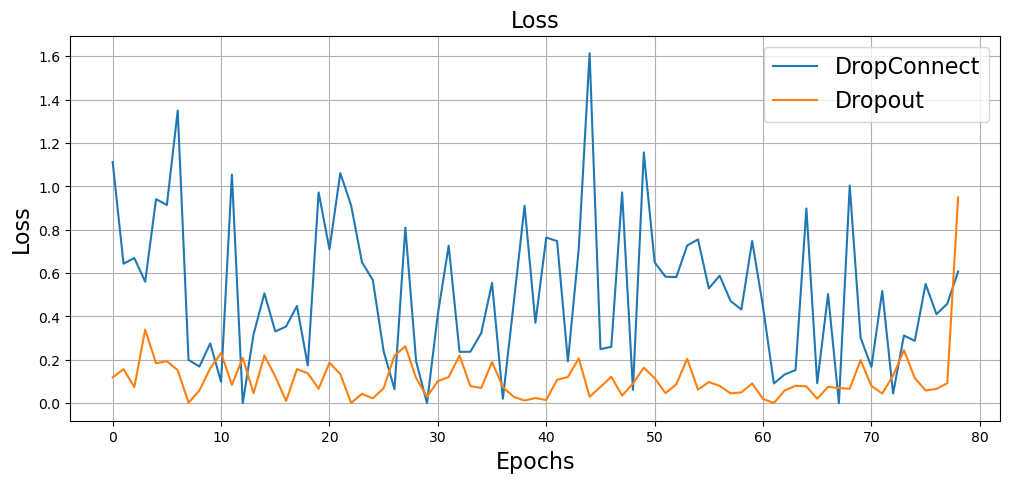

In [93]:
plt.figure(figsize=(12, 5))

plt.title("Loss", fontsize=16)
plt.plot(losses, label="DropConnect")
plt.plot(losses_dropout, label="Dropout")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()
plt.show()

Опыт показал, что как минимум на трейне, DropConnect работает немного хуже, он немного медленнее сходится. И в целом по графику, видно, что в среднем лосс от DropConnect выше.

### Часть 3: Layer Normalization

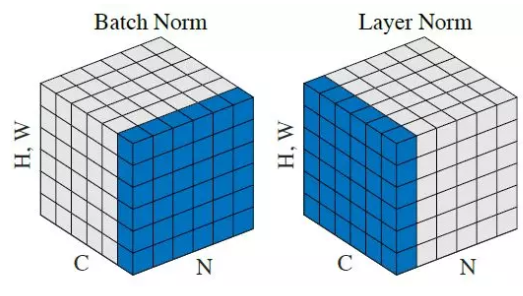

#### 3.1 Реализуйте Layer Normalization **(2 балл)**

In [100]:
# полезные функции: .std(dim), .mean(dim)

class LayerNormalization(nn.Module):
    def __init__(self, normalized_shape, eps=1e-05, elementwise_affine=True):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.D = len(normalized_shape)
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        if self.elementwise_affine:
            self.gamma = nn.Parameter(torch.ones(normalized_shape))
            self.beta = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x):
        mean = x.mean([-i for i in range(self.D, 0, -1)], keepdim=True)
        var = x.var([-i for i in range(self.D, 0, -1)], keepdim=True, unbiased=False)
        y = (x - mean) / torch.sqrt(var + self.eps)
        if self.elementwise_affine:
            return y * self.gamma + self.beta
        return y

#### Сравните графики обучения нейроных сетей:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Layer normalization между всеми слоями

In [95]:
layers = [
    nn.Linear(196, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
]

network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses_wo = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses_wo.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses_wo)))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.302550
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.573402
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.194575
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.255404
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.266057
Test Epoch: 0	Loss: 0.152707
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.159729
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.202867
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.168507
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.142627
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.076027
Test Epoch: 1	Loss: 0.121153
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.135704
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.169610
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.098155
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.071164
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.121742
Test Epoch: 2	Loss: 0.080454
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.077455
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.051537
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.123195
Train Epoch: 3 [38400/60000 (64%)

In [101]:
layers = [
    nn.Linear(196, 128),
    LayerNormalization([128]),
    nn.ReLU(),
    nn.Linear(128, 128),
    LayerNormalization([128]),
    nn.ReLU(),
    nn.Linear(128, 10)
]

network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses_ln = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses_ln.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses_ln)))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.352412
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.339310
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.211700
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.147319
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.095790
Test Epoch: 0	Loss: 0.119528
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.166318
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.041321
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.175474
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.091735
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.041775
Test Epoch: 1	Loss: 0.083218
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.035468
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.117776
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.098132
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.117324
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.057171
Test Epoch: 2	Loss: 0.078441
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.158591
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.020325
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.032757
Train Epoch: 3 [38400/60000 (64%)

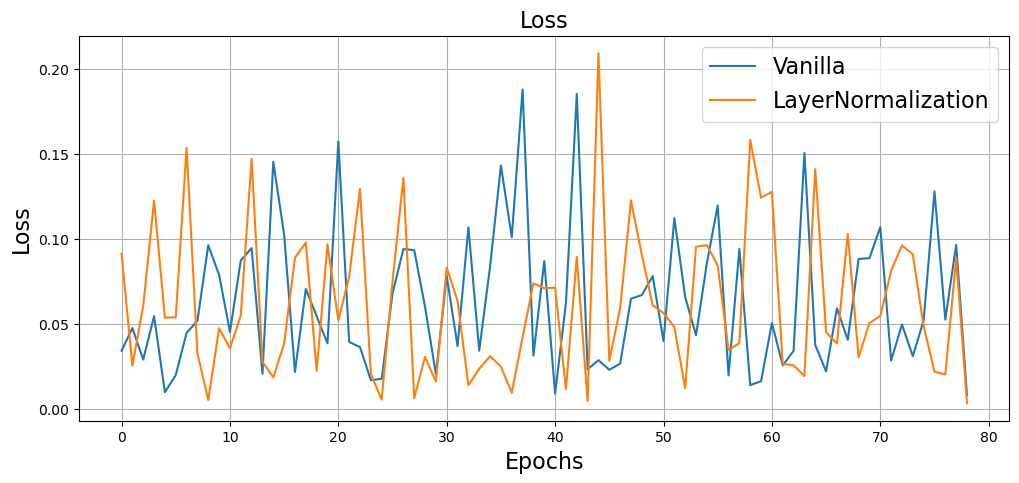

In [102]:
plt.figure(figsize=(12, 5))

plt.title("Loss", fontsize=16)
plt.plot(losses_wo, label="Vanilla")
plt.plot(losses_ln, label="LayerNormalization")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()
plt.show()

По рисунку не очень не очень понятно, однако в среднем LayerNormalization помогает ускорить обучение